In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import seaborn as sns

In [41]:
df = pd.read_csv("data/cleaned_books.csv")

df.head()

,Title,Price,Availability,Rating,Category,Price_clean,Rating_clean,Title_clean,Category_clean,Availability_clean,Hashtags,Mentions,Keywords
0,A Light in the Attic,Â£51.77,In stock,Three,Poetry,51.77,3,a light in the attic,poetry,1,[],[],"['light', 'attic']"
1,Tipping the Velvet,Â£53.74,In stock,One,Historical Fiction,53.74,1,tipping the velvet,historical fiction,1,[],[],"['tipping', 'velvet']"
2,Soumission,Â£50.10,In stock,One,Fiction,50.10,1,soumission,fiction,1,[],[],['soumission']
3,Sharp Objects,Â£47.82,In stock,Four,Mystery,47.82,4,sharp objects,mystery,1,[],[],"['sharp', 'objects']"
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,Five,History,54.23,5,sapiens: a brief history of humankind,history,1,[],[],"['sapiens:', 'brief', 'history', 'humankind']"


Intercept: 34.23490890915297
Slope (Coefficient): 0.28696915687326285
R² Score: 0.0008108133927703376


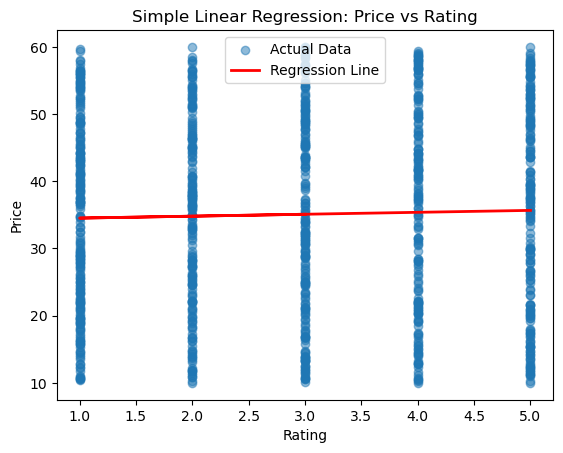

In [42]:
# Simple linear regression (Price ~ Rating)

# Features (X) and target (y)
X = df[['Rating_clean']]   # independent variable
y = df['Price_clean']      # dependent variable

# Build and fit the model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Model coefficients
print("Intercept:", model.intercept_)
print("Slope (Coefficient):", model.coef_[0])
print("R² Score:", model.score(X, y))

# Visualization
plt.scatter(X, y, alpha=0.5, label="Actual Data")
plt.plot(X, y_pred, color="red", linewidth=2, label="Regression Line")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.title("Simple Linear Regression: Price vs Rating")
plt.legend()
plt.show()

In [43]:
# Combine features for similarity

df['Combined'] = (
    df['Title_clean'].fillna('') + " " +
    df['Category_clean'].fillna('') + " " +
    df['Rating_clean'].astype(str) + " " +
    df['Price_clean'].astype(str)
)

# Vectorize text
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['Combined'])

# Compute similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Recommendation function
def recommend_books(title, n=5):
    if title not in df['Title'].values:
        return f"'{title}' not found in dataset."
    
    idx = df.index[df['Title'] == title][0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Top n (excluding itself)
    top_books = [df.iloc[i[0]]['Title'] for i in sim_scores[1:n+1]]
    return top_books

# Example: recommend 5 books similar to a given title
print("Recommendations for 'A Light in the Attic':")
print(recommend_books("A Light in the Attic", n=5))

Recommendations for 'A Light in the Attic':
['The Crossover', 'All the Light We Cannot See', 'Leave This Song Behind: Teen Poetry at Its Best', 'The Light of the Fireflies', 'Quarter Life Poetry: Poems for the Young, Broke and Hangry']


Average Price by Category:
Category_clean
suspense              58.330000
novels                54.810000
politics              53.613333
health                51.452500
new adult             46.383333
christian             42.496667
sports and games      41.166000
self help             40.620000
travel                39.794545
fantasy               39.749149
art                   38.520000
parenting             37.350000
history               37.295000
autobiography         37.053333
womens fiction        36.791176
cultural              36.580000
classics              36.545263
contemporary          36.200000
fiction               36.066615
poetry                35.974211
horror                35.949412
short stories         35.880000
add a comment         35.796418
music                 35.636923
young adult           35.449074
spirituality          35.098333
sequential art        34.572267
default               34.392697
christian fiction     34.385000
nonfiction            34.26018

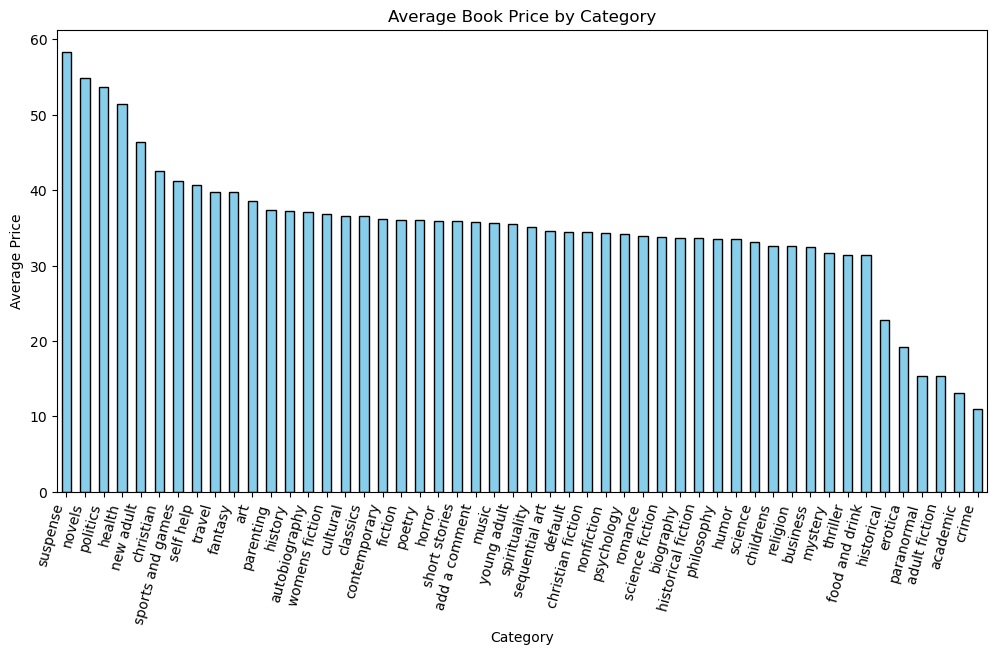

In [44]:
# Group by category and calculate mean price

category_price = df.groupby("Category_clean")["Price_clean"].mean().sort_values(ascending=False)

print("Average Price by Category:")
print(category_price)

# Visualization
plt.figure(figsize=(12,6))
category_price.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Average Book Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.xticks(rotation=75, ha="right")
plt.show()

Price statistics by availability:
                    count       mean        std   min     25%   50%     75%  \
Availability_clean                                                            
1                   999.0  35.073123  14.453659  10.0  22.105  36.0  47.475   

                      max  
Availability_clean         
1                   59.99  


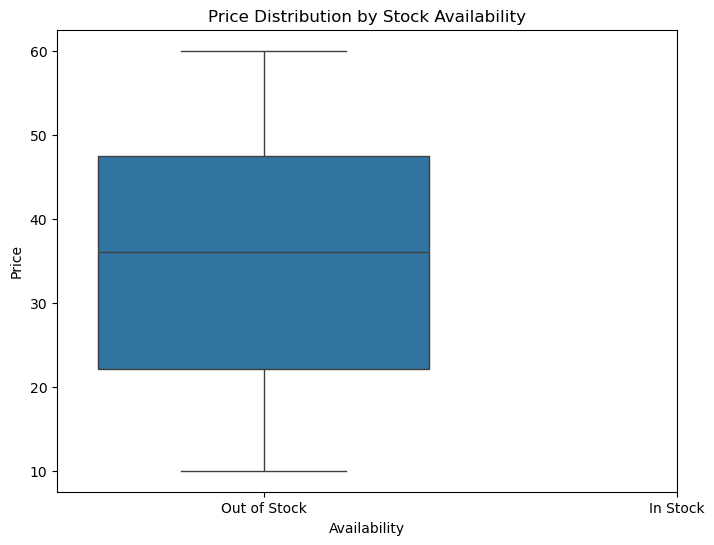

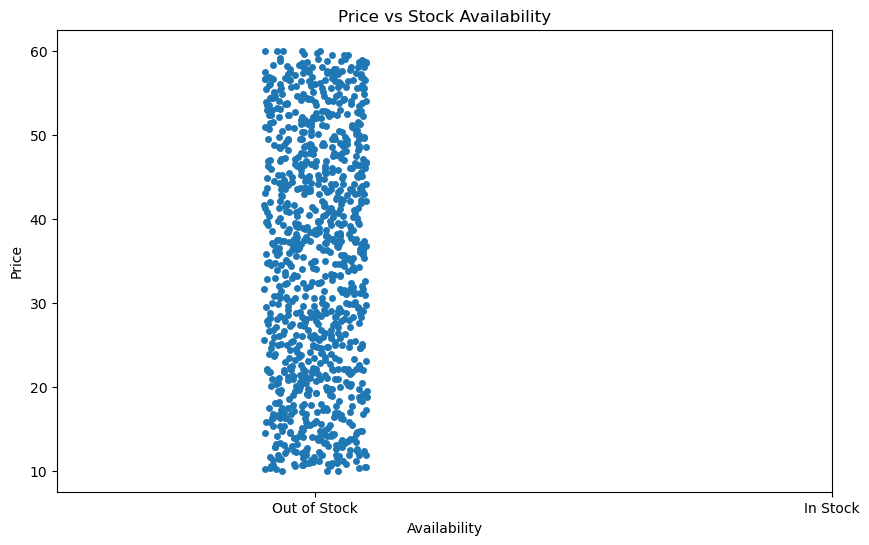

In [45]:
# Ensure Availability_clean is numeric: 1 = In stock, 0 = Out of stock

df['Availability_clean'] = df['Availability'].str.lower().str.contains('in stock').astype(int)

# Summary statistics by availability
availability_stats = df.groupby('Availability_clean')['Price_clean'].describe()
print("Price statistics by availability:")
print(availability_stats)

# Boxplot: Price vs Availability
plt.figure(figsize=(8,6))
sns.boxplot(x='Availability_clean', y='Price_clean', data=df)
plt.xticks([0,1], ['Out of Stock', 'In Stock'])
plt.title('Price Distribution by Stock Availability')
plt.ylabel('Price')
plt.xlabel('Availability')
plt.show()

# Scatter plot: Price vs Availability (jitter for visualization)
plt.figure(figsize=(10,6))
sns.stripplot(x='Availability_clean', y='Price_clean', data=df, jitter=0.1)
plt.xticks([0,1], ['Out of Stock', 'In Stock'])
plt.title('Price vs Stock Availability')
plt.ylabel('Price')
plt.xlabel('Availability')
plt.show()